In [1]:
import sys, platform, os
import numpy as np
import matplotlib.pyplot as plt
import scipy

import camb
from camb import model, initialpower

import healpy as hp

import torch
import torch.nn as nn
from torch.nn import Sequential, Linear, ReLU, ModuleList, LayerNorm
import torch.nn.functional as F

from healpy.projector import GnomonicProj
from scipy.stats import binned_statistic_2d
from scipy.interpolate import griddata
from scipy.interpolate import interpn

from scipy.ndimage import gaussian_filter

In [2]:
soft_path = "/home/belen/Doctorado/ML/curvesky/polarizacion/soft/source/" #put software path
sys.path.insert(0, os.path.abspath(soft_path))

In [3]:
import projections as pj
import utilities
import pickle
import PowerSpectrum as PP

/home/belen/miniconda3/envs/torch_cmb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
sky_region = pj.sph_mask(nside=512, radius=40, move=True)
mask40, valid_index, vecs, vec_center, theta_idx, phi_idx, lonc, latc = sky_region.make_mask()
maskSO, nhitsSO, valid_index_SO, vecs_SO, vec_center_SO, theta_idx_SO, phi_idx_SO, lonc_SO, latc_SO = sky_region.make_SO_mask()


In [5]:
theta0, phi0 = hp.vec2ang(vec_center)
theta, phi = hp.vec2ang(vecs)
proj = pj.proj_2d(lonc, latc, theta_idx, phi_idx, vec_center, nbins=512, fact=8)
z_eq, z_tan, z_str = proj.proj_conventions(vecs, vec_center)

theta0_SO, phi0_SO = hp.vec2ang(vec_center_SO)
theta_SO, phi_SO = hp.vec2ang(vecs_SO)
proj_SO = pj.proj_2d(lonc_SO, latc_SO, theta_idx_SO, phi_idx_SO, vec_center_SO, nbins=704, fact=8)
z_eq_SO, z_tan_SO, z_str_SO = proj.proj_conventions(vecs_SO, vec_center_SO)

In [9]:

ells = [200, 400, 600, 800]
nside = 512
lmax = 3*nside - 1
fwhm = 23
fwhm_rad = np.deg2rad(fwhm/ 60.0)

B_ell = utilities.bl(fwhm_rad, lmax)
W_ell = B_ell

In [12]:
ele = np.arange(lmax + 1)

In [10]:
Cl = np.zeros((len(ells), lmax + 1))
m = np.zeros((len(ells), hp.nside2npix(nside)))
for i, ell0 in enumerate(ells):
  Cl[i, ell0] = 1.0
  alm = hp.synalm(Cl[i], lmax=lmax, new=True)   # random realization with that Cl
  alm_beam = hp.almxfl(alm, W_ell)              # apply beam (and pixwin if included)
  m[i] = hp.alm2map(alm_beam, nside=nside, lmax=lmax, verbose=False)


/tmp/ipykernel_14474/1771376290.py:7: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  m[i] = hp.alm2map(alm_beam, nside=nside, lmax=lmax, verbose=False)


Text(0.5, 0, '$\\ell$')

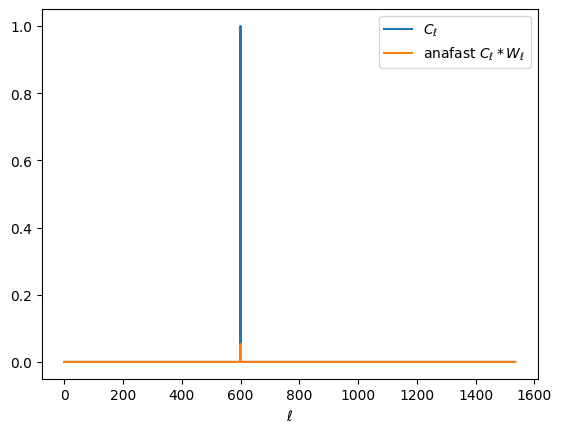

In [21]:
plt.plot(ele[:lmax+1], Cl[2], label=r'$C_\ell$')
plt.plot(ele[:lmax+1], hp.anafast(m[2]), label=r'anafast $C_\ell*W_\ell$')
plt.legend()
plt.xlabel(r"$\ell$")

In [19]:
ells

[200, 400, 600, 800]

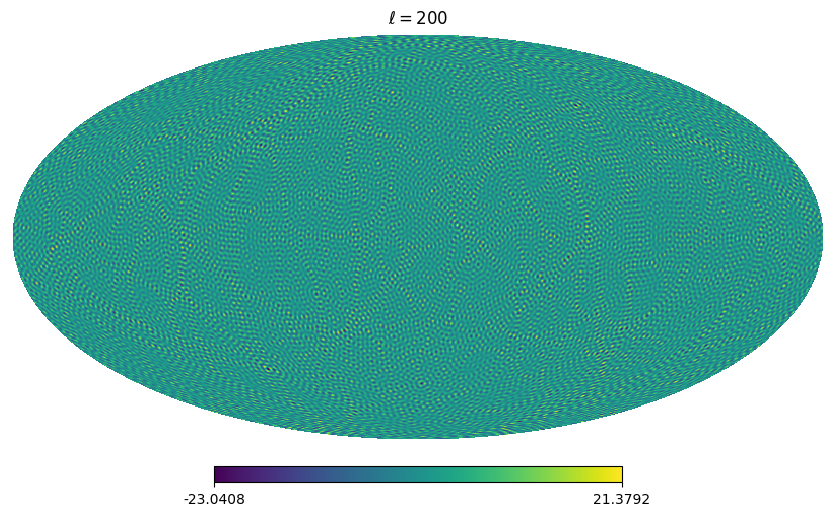

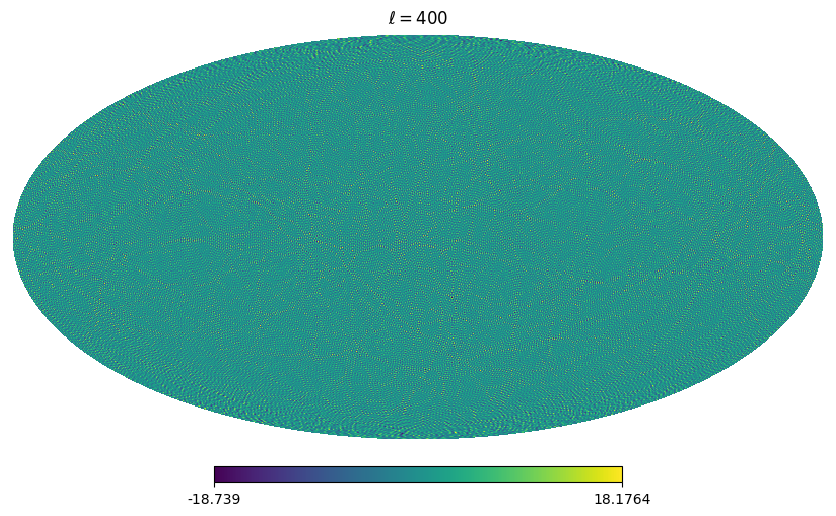

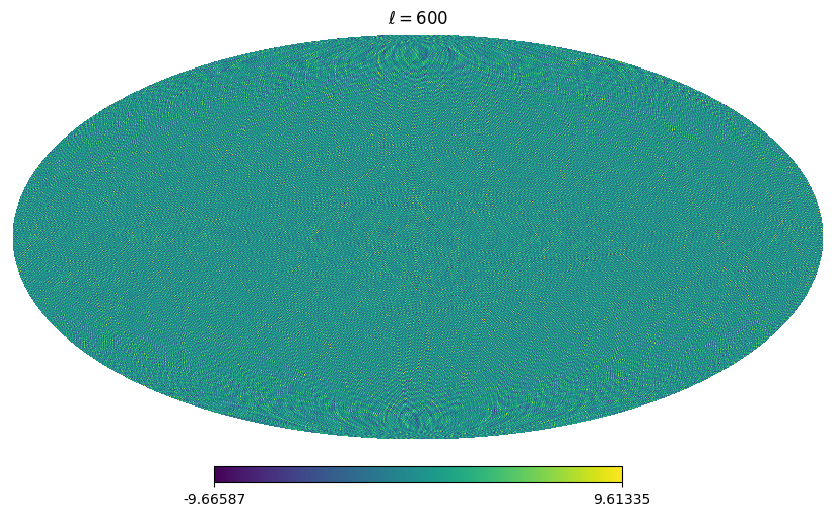

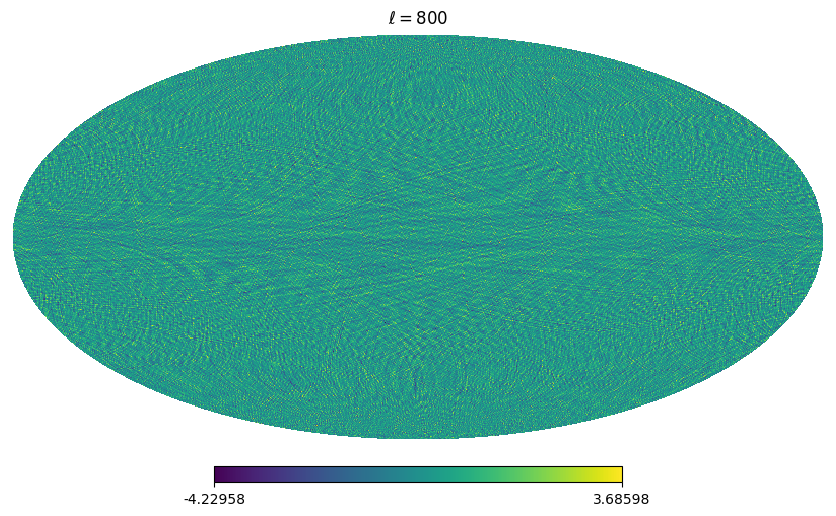

In [20]:
hp.mollview(m[0], title=r'$\ell = 200$')
hp.mollview(m[1], title=r'$\ell = 400$')
hp.mollview(m[2], title=r'$\ell = 600$')
hp.mollview(m[3], title=r'$\ell = 800$')

In [24]:
grid_str = np.zeros((len(ells), 512, 512))
grid_eq = np.zeros((len(ells), 512, 512))
grid_gnom = np.zeros((len(ells), 512, 512))

for i in range(len(ells)):
    data_piece = m[i][valid_index]
    grid_str[i,:,:], _, _, inside_str, z_str_inside = proj.grid_cuad(z_str, data_piece)
    grid_eq[i,:,:], _, _, inside_eq, z_eq_inside = proj.grid_cuad(z_eq, data_piece)
    grid_gnom[i,:,:], _, _, inside_gnom, z_gnom_inside = proj.grid_cuad(z_tan, data_piece)

In [25]:
_,_,dx_gnom = utilities.calculate_res(z_gnom_inside, 512, 512)
_,_,dx_eq = utilities.calculate_res(z_eq_inside, 512, 512)
_,_,dx_str = utilities.calculate_res(z_str_inside, 512, 512)

Text(0.5, 1.0, 'stereographic')

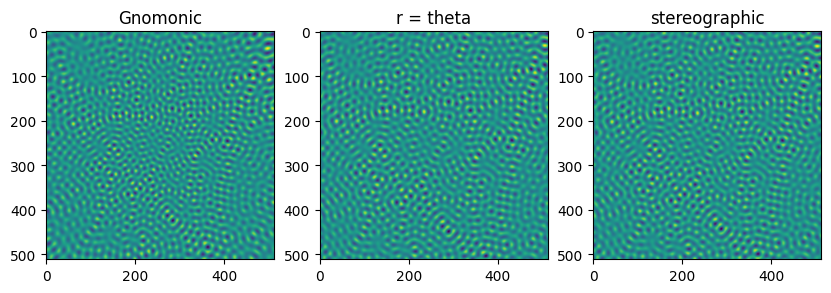

In [27]:
fig, ax = plt.subplots(1,3, figsize=(10,5))

ax[0].imshow(grid_gnom[0])
ax[0].set_title('Gnomonic')
ax[1].imshow(grid_eq[0])
ax[1].set_title('r = theta')
ax[2].imshow(grid_str[0])
ax[2].set_title('stereographic')

In [28]:
ell_flat_eq, _  = utilities.power_spectrum_flat(Cl[0], 512, 512, dx_eq, dx_eq)
ell_flat_str, _  = utilities.power_spectrum_flat(Cl[0], 512, 512, dx_str, dx_str)
ell_flat_gnom, _  = utilities.power_spectrum_flat(Cl[0], 512, 512, dx_gnom, dx_gnom)


/home/belen/Doctorado/ML/curvesky/polarizacion/soft/source/utilities.py:1087: RuntimeWarning: divide by zero encountered in log
  interp = scipy.interpolate.interp1d(np.log(ell_ql[1:]),np.log(cl_plane[1:]), kind='linear',fill_value=0,bounds_error=False)


In [29]:
ell_flat_eq

array([   0.        ,    6.36403065,   12.72806129, ..., 1616.47631144,
       1622.84029296, 1629.20427486], shape=(131584,))

In [31]:
Cl_grid_str = np.zeros((len(ells), len(ell_flat_str)))
Cl_grid_eq = np.zeros((len(ells), len(ell_flat_eq)))
Cl_grid_gnom = np.zeros((len(ells), len(ell_flat_gnom)))

for i in range(len(ells)):

    Cl_grid_str[i,:] = utilities.powerauto(grid_str[i], 512, 512, dx_str, dx_str)
    Cl_grid_eq[i,:] = utilities.powerauto(grid_eq[i], 512, 512, dx_eq, dx_eq)
    Cl_grid_gnom[i,:] = utilities.powerauto(grid_gnom[i], 512, 512, dx_gnom, dx_gnom)



In [32]:
Clmap = np.zeros((len(ells), lmax+1))
for i in range(len(ells)):
    Clmap[i] = hp.anafast(m[i])

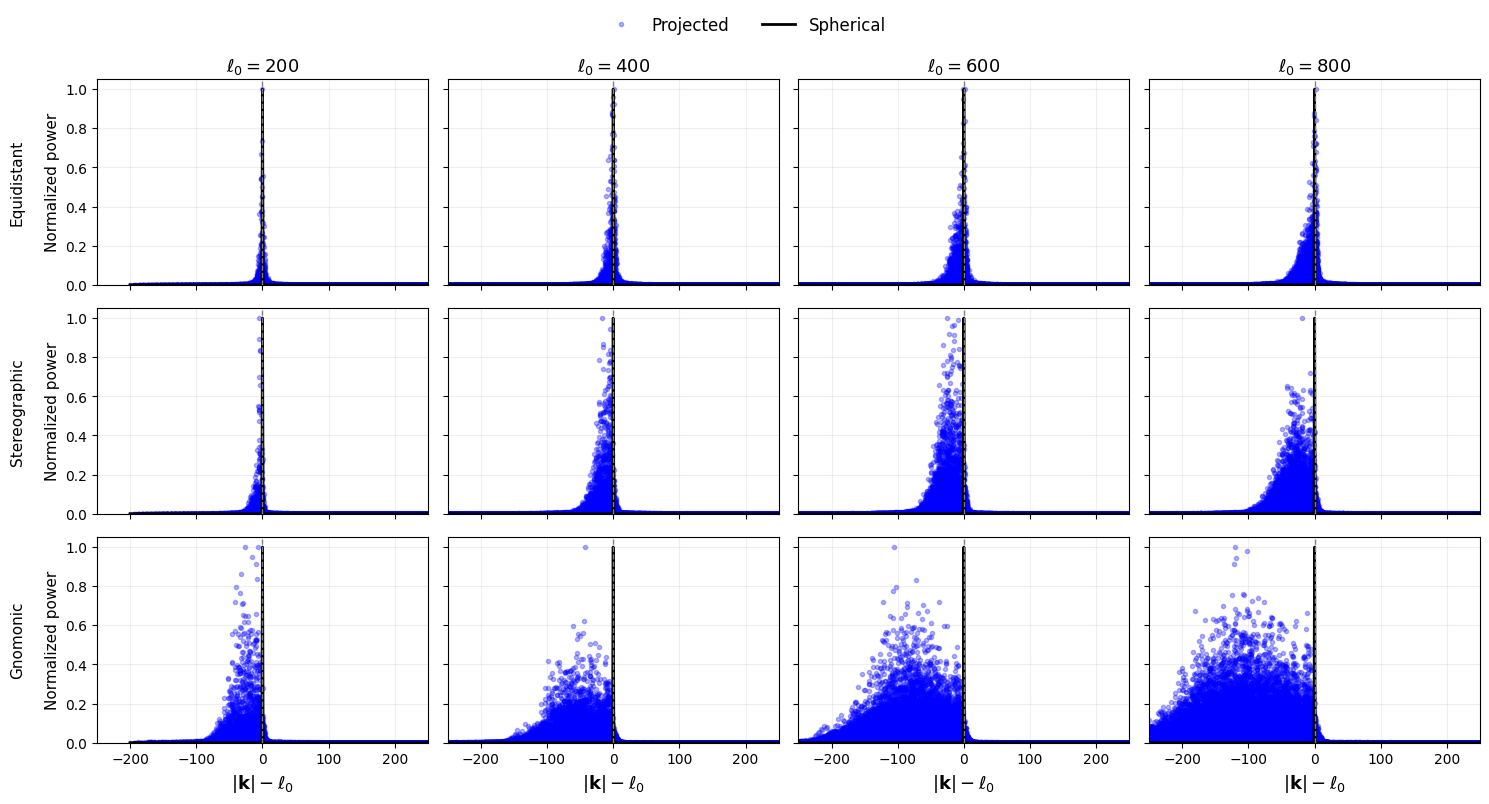

In [49]:
# Input spherical modes
ells_input = [200, 400, 600, 800]

# Projection information
projections = [
    ("Equidistant",   ell_flat_eq,   Cl_grid_eq),    
    ("Stereographic", ell_flat_str,  Cl_grid_str),
    ("Gnomonic",      ell_flat_gnom, Cl_grid_gnom),
]

fig, axes = plt.subplots(3, 4, figsize=(15, 8), sharex=True,sharey=True)

# Range around ell_0
delta_ell_max = 250

for i, (proj_name, ell_flat, Cl_grid) in enumerate(projections):

    for j, ell0 in enumerate(ells_input):

        ax = axes[i, j]
        cl_sph = Clmap[j].copy()

        # Normalize
        if np.max(cl_sph) > 0:
            cl_sph = cl_sph / np.max(cl_sph)

        # Center around ell_0
        delta_ell_sph = ele[:lmax+1] - ell0
        
        cl_pln = Cl_grid[j].copy()

        # Normalize
        if np.max(cl_pln) > 0:
            cl_pln = cl_pln / np.max(cl_pln)

        # Center Fourier modes around ell_0
        delta_ell_pln = ell_flat - ell0
        ax.plot(delta_ell_pln, cl_pln, 'b.', alpha=0.3, label="Projected")
        ax.plot(delta_ell_sph, cl_sph, color="black", lw=2, label="Spherical")
        ax.axvline(0,color="gray",ls="--",lw=1)
        
        ax.set_xlim(-delta_ell_max, delta_ell_max)
        ax.set_ylim(0, 1.05)

        # Column titles
        if i == 0:
            ax.set_title(rf"$\ell_0={ell0}$",fontsize=13)

        # Projection labels
        if j == 0:
            ax.set_ylabel(proj_name + "\n\nNormalized power",fontsize=11)

        # x-axis only in bottom row
        if i == 2:
            ax.set_xlabel(r"$|\mathbf{k}|-\ell_0$", fontsize=13)

        ax.grid(alpha=0.2)


handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(handles,labels,loc="upper center",ncol=2,bbox_to_anchor=(0.5, 1.01),frameon=False, fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('mixing.png', bbox_inches='tight')

plt.show()

In [50]:
def compute_fwhm(ell, Cl):
    Cln = Cl / np.max(Cl)
    mask = Cln > 0.5
    return ell[mask].max() - ell[mask].min()

def compute_width(ell, Cl):
    w = Cl / np.sum(Cl)
    mean = np.sum(ell * w)
    var = np.sum((ell - mean)**2 * w)
    return np.sqrt(var)


def width_asymmetric(ell, Cl):
    
    ell = np.asarray(ell)
    Cl = np.asarray(Cl)
    order = np.argsort(ell)
    ell = ell[order]
    Cl = Cl[order]
    Cl_pos = np.maximum(Cl, 0.0)  # o np.abs(Cl) si querés medir “magnitud”
    s = np.sum(Cl_pos)
    if s <= 0:
        return None
    w = Cl_pos / s
    cdf = np.cumsum(w)
    l16 = ell[np.searchsorted(cdf, 0.16)]
    l50 = ell[np.searchsorted(cdf, 0.50)]
    l84 = ell[np.searchsorted(cdf, 0.84)]
    return l16, l50, l84, l84 - l16, l50 - l16, l84 - l50

In [51]:
width_str_200 = width_asymmetric(ell_flat_str, Cl_grid_str[0])
width_str_400 = width_asymmetric(ell_flat_str, Cl_grid_str[1])
width_str_600 = width_asymmetric(ell_flat_str, Cl_grid_str[2])
width_str_800 = width_asymmetric(ell_flat_str, Cl_grid_str[3])

width_eq_200 = width_asymmetric(ell_flat_eq, Cl_grid_eq[0])
width_eq_400 = width_asymmetric(ell_flat_eq, Cl_grid_eq[1])
width_eq_600 = width_asymmetric(ell_flat_eq, Cl_grid_eq[2])
width_eq_800 = width_asymmetric(ell_flat_eq, Cl_grid_eq[3])

width_gnom_200 = width_asymmetric(ell_flat_gnom, Cl_grid_gnom[0])
width_gnom_400 = width_asymmetric(ell_flat_gnom, Cl_grid_gnom[1])
width_gnom_600 = width_asymmetric(ell_flat_gnom, Cl_grid_gnom[2])
width_gnom_800 = width_asymmetric(ell_flat_gnom, Cl_grid_gnom[3])

In [52]:
ells

[200, 400, 600, 800]

In [55]:
print(f"{'ell':>4} | {'width, str':>8}")
print("-" * 30)
print(f"{ells[0]:>4} | {width_str_200[3]:8.3f}")
print(f"{ells[1]:>4} | {width_str_400[3]:8.3f}")
print(f"{ells[2]:>4} | {width_str_600[3]:8.3f}")
print(f"{ells[3]:>4} | {width_str_800[3]:8.3f}")

 ell | width, str
------------------------------
 200 |   10.692
 400 |   22.269
 600 |   31.623
 800 |   44.742


In [56]:
print(f"{'ell':>4} | {'width, eq':>8}")
print("-" * 30)
print(f"{ells[0]:>4} | {width_eq_200[3]:8.3f}")
print(f"{ells[1]:>4} | {width_eq_400[3]:8.3f}")
print(f"{ells[2]:>4} | {width_eq_600[3]:8.3f}")
print(f"{ells[3]:>4} | {width_eq_800[3]:8.3f}")

 ell | width, eq
------------------------------
 200 |    7.446
 400 |   11.040
 600 |   17.392
 800 |   23.814


In [57]:
print(f"{'ell':>4} | {'width, gnom':>8}")
print("-" * 30)
print(f"{ells[0]:>4} | {width_gnom_200[3]:8.3f}")
print(f"{ells[1]:>4} | {width_gnom_400[3]:8.3f}")
print(f"{ells[2]:>4} | {width_gnom_600[3]:8.3f}")
print(f"{ells[3]:>4} | {width_gnom_800[3]:8.3f}")

 ell | width, gnom
------------------------------
 200 |   36.090
 400 |   72.896
 600 |  100.335
 800 |  134.305
